In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import matplotlib.pyplot as plt
import numpy as np
from pprint import pprint as print
from xsynth.signal import ADAPTSignalGenerator

from xsynth.device import (ADAPTX)

In [30]:
AX = ADAPTX(beam_region = "SA1")

In [31]:
XSynth = ADAPTSignalGenerator(AX, oscillator='sin', V0 = 0, V1 = 1000)
XSynth.update_variable(V0 = 800, V1 = 1200, V2 = 0, V3 = 1, V4 = 1/400)

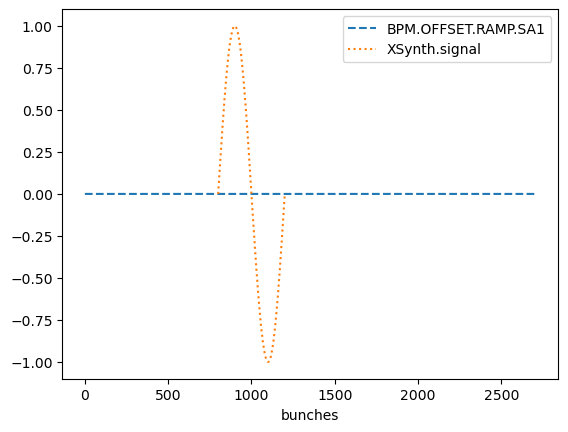

In [39]:
plt.plot(np.arange(2708), XSynth.server.read(), label = XSynth.server.ramp_location.split("/")[-1], linestyle = 'dashed')
plt.plot(XSynth.t, XSynth.signal, label = "XSynth.signal", linestyle = 'dotted')
plt.xlabel(XSynth.unit)
#plt.xlim(XSynth.t.min(), XSynth.t.max())
plt.legend()


In [40]:
from xsynth.main import Scan
from functools import partial

In [ ]:
scan_output = Scan([partial(ADAPTX, beam_region='SA3')],
            scan_vectors = [np.arange(10)],
            all_messages=False,
            display = True,
            beam_region = 'SA3',
			wait_time=1,
			write = False,
			relative_scan = False,
			oscillator_variables=[{"V0":0,"V1":2708}],
			oscillators=['sin'],
		scan_variables=['V2'],
        fix_beam_region = False
			
            )

##### NEXT STEP IS TO GET PLOTTING WORKING

TypeError: __init__() got an unexpected keyword argument 'fix_beam_region'

In [48]:
scan_output.__dict__

{'all_messages': False,
 'generators': [<xsynth.signal.ADAPTSignalGenerator at 0x79bdc5c18550>],
 'scan_variables': ['V2'],
 'scan_properties': {'scan_vectors': [array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]},
 'wait_time': 1,
 'plot_display': True,
 'timestamps': [datetime.timedelta(microseconds=212545),
  datetime.timedelta(microseconds=279651),
  datetime.timedelta(microseconds=329585),
  datetime.timedelta(microseconds=396604),
  datetime.timedelta(microseconds=446724),
  datetime.timedelta(microseconds=497576),
  datetime.timedelta(microseconds=550367),
  datetime.timedelta(microseconds=609894),
  datetime.timedelta(microseconds=661529),
  datetime.timedelta(microseconds=711534)],
 'signals': [[array([], dtype=float64)],
  [array([], dtype=float64)],
  [array([], dtype=float64)],
  [array([], dtype=float64)],
  [array([], dtype=float64)],
  [array([], dtype=float64)],
  [array([], dtype=float64)],
  [array([], dtype=float64)],
  [array([], dtype=float64)],
  [array([], dtype=float64)]]}

In [371]:
import pydoocs
pydoocs.read(f"XFEL.FEEDBACK/KICKERDC_BETA/CONTROL/BPM.PULSES.SA2.INDX")['data']

array([160], dtype=uint32)